In [1]:
!pip install pandas_datareader

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr
import datetime

In [3]:
# Tesla's historical annual revenue (in billions)
# Source: Macrotrends.net
data = {
    'Year': [2020, 2021, 2022, 2023, 2024, 2025],
    'Revenue': [31.54, 53.82, 81.46, 96.77, 97.69, 94.83]
}

tesla_revenue = pd.DataFrame(data)
print(tesla_revenue)

   Year  Revenue
0  2020    31.54
1  2021    53.82
2  2022    81.46
3  2023    96.77
4  2024    97.69
5  2025    94.83


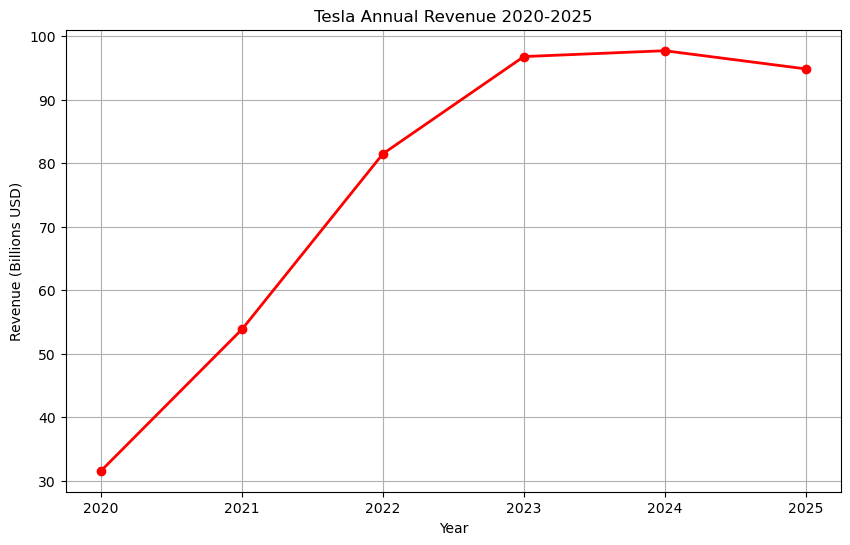

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(tesla_revenue['Year'], tesla_revenue['Revenue'], marker='o', color='red', linewidth=2)
plt.title('Tesla Annual Revenue 2020-2025')
plt.xlabel('Year')
plt.ylabel('Revenue (Billions USD)')
plt.grid(True)
plt.show()

In [5]:
tesla_revenue['Growth Rate'] = tesla_revenue['Revenue'].pct_change() * 100
print(tesla_revenue)

   Year  Revenue  Growth Rate
0  2020    31.54          NaN
1  2021    53.82    70.640457
2  2022    81.46    51.356373
3  2023    96.77    18.794500
4  2024    97.69     0.950708
5  2025    94.83    -2.927628


In [6]:
avg_growth = tesla_revenue['Growth Rate'].mean()
print(f"Average Annual Revenue Growth Rate: {avg_growth:.2f}%")

Average Annual Revenue Growth Rate: 27.76%


In [7]:
recent_growth = tesla_revenue['Growth Rate'].iloc[-2:]
print(f"Most Recent Growth Rates:")
print(recent_growth)

Most Recent Growth Rates:
4    0.950708
5   -2.927628
Name: Growth Rate, dtype: float64


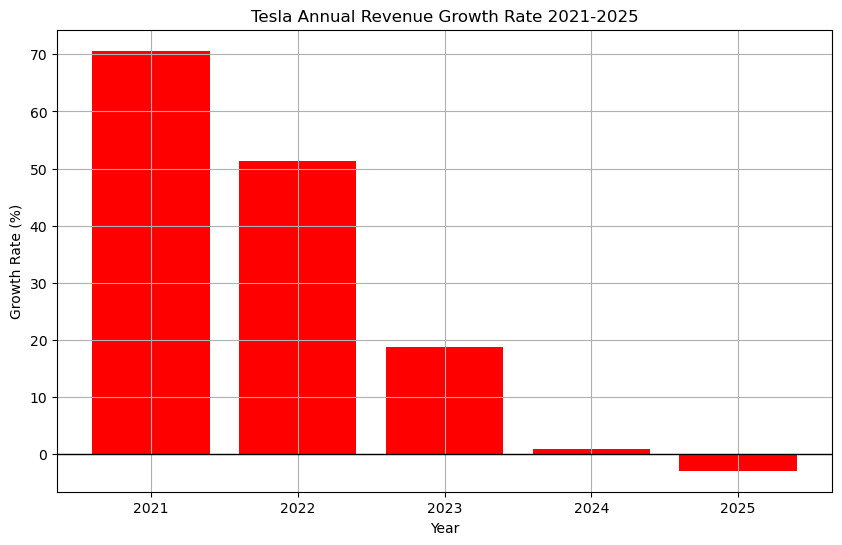

In [8]:
growth_data = tesla_revenue.dropna()

plt.figure(figsize=(10, 6))
plt.bar(growth_data['Year'], growth_data['Growth Rate'], color='red')
plt.title('Tesla Annual Revenue Growth Rate 2021-2025')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.axhline(y=0, color='black', linewidth=1)
plt.grid(True)
plt.show()

In [9]:
# Revenue Projections
projection_years = [2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035]

growth_rates = [
    -0.03,  # 2026: continued decline
    -0.02,  # 2027: continued decline
     0.02,  # 2028: bottoming out
     0.05,  # 2029: gradual recovery
     0.06,  # 2030: gradual recovery
     0.07,  # 2031: gradual recovery
     0.08,  # 2032: gradual recovery
     0.05,  # 2033: stable mature growth
     0.04,  # 2034: stable mature growth
     0.03,  # 2035: stable mature growth
]

# Start from Tesla's last reported revenue
projected_revenue = []
last_revenue = 94.83

for rate in growth_rates:
    last_revenue = last_revenue * (1 + rate)
    projected_revenue.append(round(last_revenue, 2))

projection_df = pd.DataFrame({
    'Year': projection_years,
    'Projected Revenue': projected_revenue
})

print(projection_df)

   Year  Projected Revenue
0  2026              91.99
1  2027              90.15
2  2028              91.95
3  2029              96.55
4  2030             102.34
5  2031             109.50
6  2032             118.26
7  2033             124.18
8  2034             129.14
9  2035             133.02


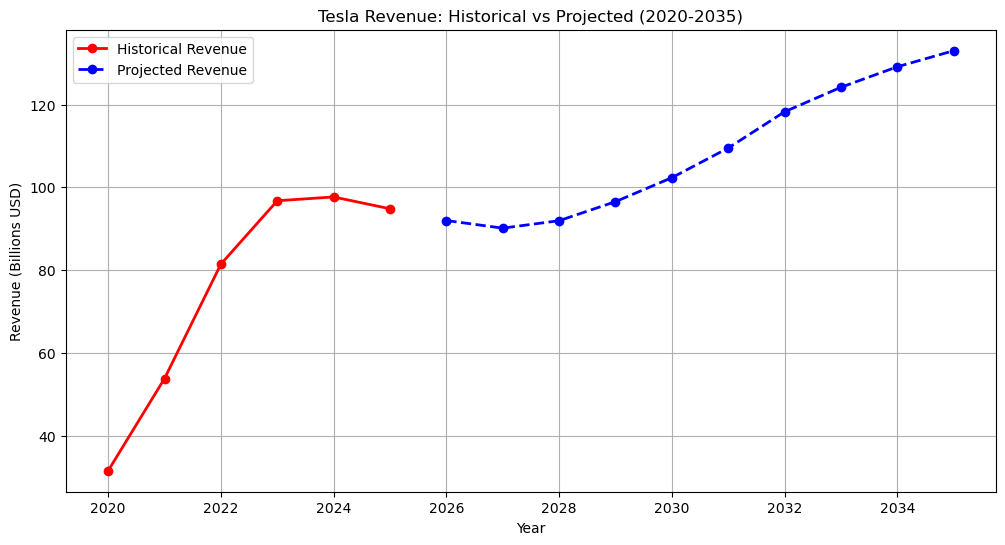

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(tesla_revenue['Year'], tesla_revenue['Revenue'], 
         marker='o', color='red', linewidth=2, label='Historical Revenue')
plt.plot(projection_df['Year'], projection_df['Projected Revenue'], 
         marker='o', color='blue', linewidth=2, linestyle='--', label='Projected Revenue')
plt.title('Tesla Revenue: Historical vs Projected (2020-2035)')
plt.xlabel('Year')
plt.ylabel('Revenue (Billions USD)')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Operating Margin Projections
operating_margins = {
    2026: 0.037,  # 3.7% - continued pressure
    2027: 0.038,  # 3.8% - continued pressure
    2028: 0.042,  # 4.2% - stabilizing
    2029: 0.050,  # 5.0% - gradual recovery
    2030: 0.058,  # 5.8% - gradual recovery
    2031: 0.065,  # 6.5% - gradual recovery
    2032: 0.075,  # 7.5% - operating leverage kicking in
    2033: 0.083,  # 8.3% - operating leverage kicking in
    2034: 0.090,  # 9.0% - maturing
    2035: 0.095,  # 9.5% - maturing
}

# Calculate projected operating income
projection_df['Operating Margin'] = projection_df['Year'].map(operating_margins)
projection_df['Operating Income'] = round(projection_df['Projected Revenue'] * projection_df['Operating Margin'], 2)

print(projection_df)

   Year  Projected Revenue  Operating Margin  Operating Income
0  2026              91.99             0.037              3.40
1  2027              90.15             0.038              3.43
2  2028              91.95             0.042              3.86
3  2029              96.55             0.050              4.83
4  2030             102.34             0.058              5.94
5  2031             109.50             0.065              7.12
6  2032             118.26             0.075              8.87
7  2033             124.18             0.083             10.31
8  2034             129.14             0.090             11.62
9  2035             133.02             0.095             12.64


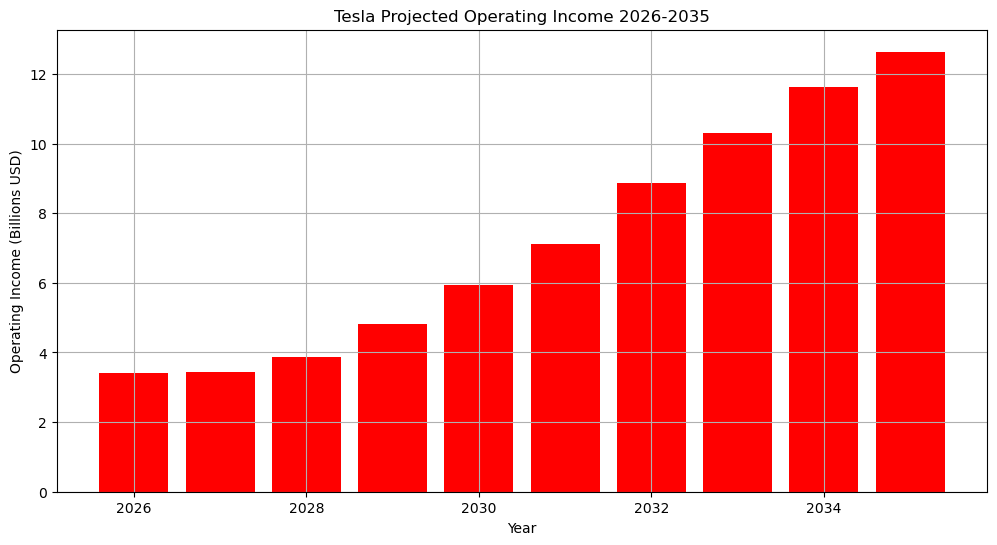

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(projection_df['Year'], projection_df['Operating Income'], color='red')
plt.title('Tesla Projected Operating Income 2026-2035')
plt.xlabel('Year')
plt.ylabel('Operating Income (Billions USD)')
plt.grid(True)
plt.show()

In [13]:
# D&A Historical Data (in billions)
da_data = {
    'Year': [2020, 2021, 2022, 2023, 2024, 2025],
    'DA': [2.322, 2.911, 3.747, 4.667, 5.368, 6.148]
}

da_df = pd.DataFrame(da_data)

# Project D&A forward at decelerating growth rates
da_growth_rates = [0.13, 0.13, 0.12, 0.12, 0.11, 0.11, 0.10, 0.10, 0.09, 0.09]

projected_da = []
last_da = 6.148

for rate in da_growth_rates:
    last_da = last_da * (1 + rate)
    projected_da.append(round(last_da, 3))

projection_df['DA'] = projected_da
print(projection_df)

   Year  Projected Revenue  Operating Margin  Operating Income      DA
0  2026              91.99             0.037              3.40   6.947
1  2027              90.15             0.038              3.43   7.850
2  2028              91.95             0.042              3.86   8.792
3  2029              96.55             0.050              4.83   9.848
4  2030             102.34             0.058              5.94  10.931
5  2031             109.50             0.065              7.12  12.133
6  2032             118.26             0.075              8.87  13.346
7  2033             124.18             0.083             10.31  14.681
8  2034             129.14             0.090             11.62  16.002
9  2035             133.02             0.095             12.64  17.443


In [14]:
# Capital Expenditure Projections
# Baseline from average of 2023-2025
base_capex = 9.59
capex_growth_rate = 0.04  # 4% annual growth

projected_capex = []
last_capex = base_capex

for year in projection_df['Year']:
    last_capex = last_capex * (1 + capex_growth_rate)
    projected_capex.append(round(last_capex, 3))

projection_df['Capex'] = projected_capex
print(projection_df)

   Year  Projected Revenue  Operating Margin  Operating Income      DA   Capex
0  2026              91.99             0.037              3.40   6.947   9.974
1  2027              90.15             0.038              3.43   7.850  10.373
2  2028              91.95             0.042              3.86   8.792  10.787
3  2029              96.55             0.050              4.83   9.848  11.219
4  2030             102.34             0.058              5.94  10.931  11.668
5  2031             109.50             0.065              7.12  12.133  12.134
6  2032             118.26             0.075              8.87  13.346  12.620
7  2033             124.18             0.083             10.31  14.681  13.125
8  2034             129.14             0.090             11.62  16.002  13.650
9  2035             133.02             0.095             12.64  17.443  14.196


In [15]:
# Calculate Free Cash Flow
projection_df['FCF'] = round(projection_df['Operating Income'] + projection_df['DA'] - projection_df['Capex'], 3)

print(projection_df[['Year', 'Operating Income', 'DA', 'Capex', 'FCF']])

   Year  Operating Income      DA   Capex     FCF
0  2026              3.40   6.947   9.974   0.373
1  2027              3.43   7.850  10.373   0.907
2  2028              3.86   8.792  10.787   1.865
3  2029              4.83   9.848  11.219   3.459
4  2030              5.94  10.931  11.668   5.203
5  2031              7.12  12.133  12.134   7.119
6  2032              8.87  13.346  12.620   9.596
7  2033             10.31  14.681  13.125  11.866
8  2034             11.62  16.002  13.650  13.972
9  2035             12.64  17.443  14.196  15.887


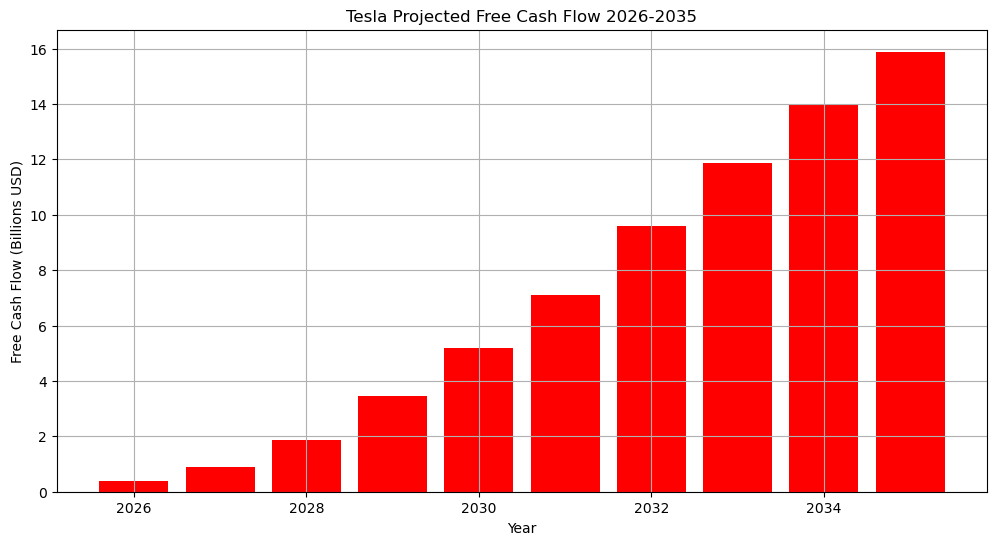

In [16]:
plt.figure(figsize=(12, 6))
plt.bar(projection_df['Year'], projection_df['FCF'], color='red')
plt.title('Tesla Projected Free Cash Flow 2026-2035')
plt.xlabel('Year')
plt.ylabel('Free Cash Flow (Billions USD)')
plt.grid(True)
plt.show() 

In [17]:
# Cost of Equity using CAPM
risk_free_rate = 0.043
beta = 1.93
market_risk_premium = 0.055

cost_of_equity = risk_free_rate + beta * market_risk_premium
print(f"Cost of Equity: {cost_of_equity * 100:.2f}%")

Cost of Equity: 14.92%


In [18]:
# WACC Calculation
risk_free_rate = 0.043
beta = 1.93
market_risk_premium = 0.055
cost_of_equity = risk_free_rate + beta * market_risk_premium

cost_of_debt = 0.05
tax_rate = 0.21
after_tax_cost_of_debt = cost_of_debt * (1 - tax_rate)

weight_of_equity = 0.9954
weight_of_debt = 0.0046

wacc = (weight_of_equity * cost_of_equity) + (weight_of_debt * after_tax_cost_of_debt)
print(f"Cost of Equity: {cost_of_equity * 100:.2f}%")
print(f"After Tax Cost of Debt: {after_tax_cost_of_debt * 100:.2f}%")
print(f"WACC: {wacc * 100:.2f}%")

Cost of Equity: 14.92%
After Tax Cost of Debt: 3.95%
WACC: 14.86%


In [19]:
# Discount FCF to Present Value
wacc = 0.1486

projected_fcf = projection_df['FCF'].values
years = range(1, 11)

discounted_fcf = []
for fcf, year in zip(projected_fcf, years):
    pv = fcf / (1 + wacc) ** year
    discounted_fcf.append(round(pv, 3))

projection_df['Discounted FCF'] = discounted_fcf
print(projection_df[['Year', 'FCF', 'Discounted FCF']])

   Year     FCF  Discounted FCF
0  2026   0.373           0.325
1  2027   0.907           0.687
2  2028   1.865           1.231
3  2029   3.459           1.987
4  2030   5.203           2.603
5  2031   7.119           3.100
6  2032   9.596           3.638
7  2033  11.866           3.917
8  2034  13.972           4.015
9  2035  15.887           3.975


In [20]:
# Sum of all discounted FCFs
sum_pv_fcf = round(sum(discounted_fcf), 3)
print(f"Sum of Present Value of FCFs: ${sum_pv_fcf} Billion")

Sum of Present Value of FCFs: $25.478 Billion


In [21]:
# Terminal Value and Enterprise Value
terminal_growth_rate = 0.025
terminal_value = projection_df['FCF'].iloc[-1] * (1 + terminal_growth_rate) / (wacc - terminal_growth_rate)
pv_terminal_value = terminal_value / (1 + wacc) ** 10

enterprise_value = sum_pv_fcf + pv_terminal_value

print(f"Terminal Value: ${round(terminal_value, 3)} Billion")
print(f"PV of Terminal Value: ${round(pv_terminal_value, 3)} Billion")
print(f"Enterprise Value: ${round(enterprise_value, 3)} Billion")

Terminal Value: $131.749 Billion
PV of Terminal Value: $32.965 Billion
Enterprise Value: $58.443 Billion


In [23]:
import numpy as np

# Sensitivity Analysis
shares_outstanding = 3.53  # Added this line
wacc_values = [0.12, 0.1486, 0.17]
tgr_values = [0.015, 0.025, 0.035]

sensitivity = []

for w in wacc_values:
    row = []
    for tgr in tgr_values:
        tv = projection_df['FCF'].iloc[-1] * (1 + tgr) / (w - tgr)
        pv_tv = tv / (1 + w) ** 10
        pv_fcf = sum([projection_df['FCF'].iloc[i] / (1 + w) ** (i + 1) for i in range(10)])
        ev = pv_fcf + pv_tv
        price = round(ev / shares_outstanding, 2)
        row.append(price)
    sensitivity.append(row)

sensitivity_df = pd.DataFrame(
    sensitivity,
    index=[f"WACC {int(w*100)}%" if w == 0.12 or w == 0.17 else "WACC 14.86%" for w in wacc_values],
    columns=[f"TGR {int(tgr*100)}%" if tgr != 0.025 else "TGR 2.5%" for tgr in tgr_values]
)

print("Sensitivity Table - Implied Share Price")
print(sensitivity_df)

Sensitivity Table - Implied Share Price
             TGR 1%  TGR 2.5%  TGR 3%
WACC 12%      22.63     24.25   26.26
WACC 14.86%   15.77     16.56   17.48
WACC 17%      12.48     12.97   13.53


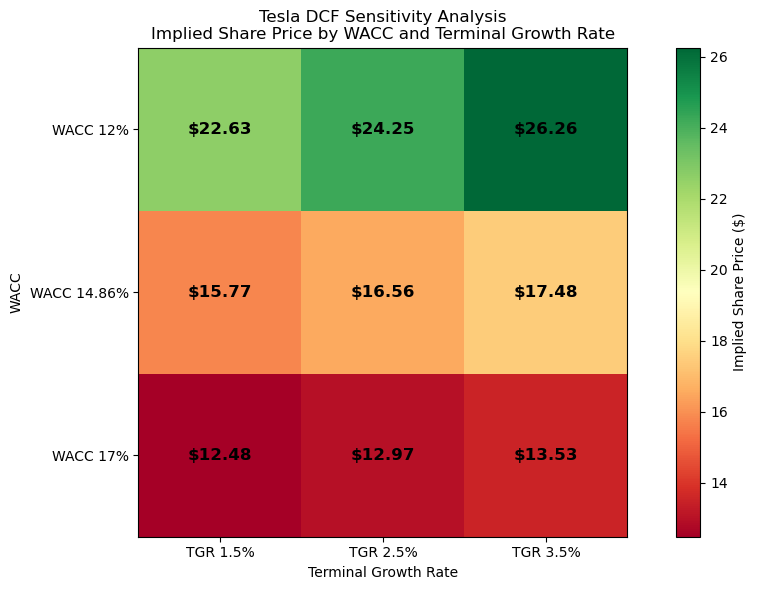

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

# Create heatmap
im = ax.imshow(sensitivity, cmap='RdYlGn')

# Add colorbar
plt.colorbar(im, ax=ax, label='Implied Share Price ($)')

# Add labels
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(['TGR 1.5%', 'TGR 2.5%', 'TGR 3.5%'])
ax.set_yticklabels(['WACC 12%', 'WACC 14.86%', 'WACC 17%'])

# Add values inside cells
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'${sensitivity[i][j]}',
                ha='center', va='center', 
                color='black', fontweight='bold', fontsize=12)

ax.set_title('Tesla DCF Sensitivity Analysis\nImplied Share Price by WACC and Terminal Growth Rate')
plt.xlabel('Terminal Growth Rate')
plt.ylabel('WACC')
plt.tight_layout()
plt.show()

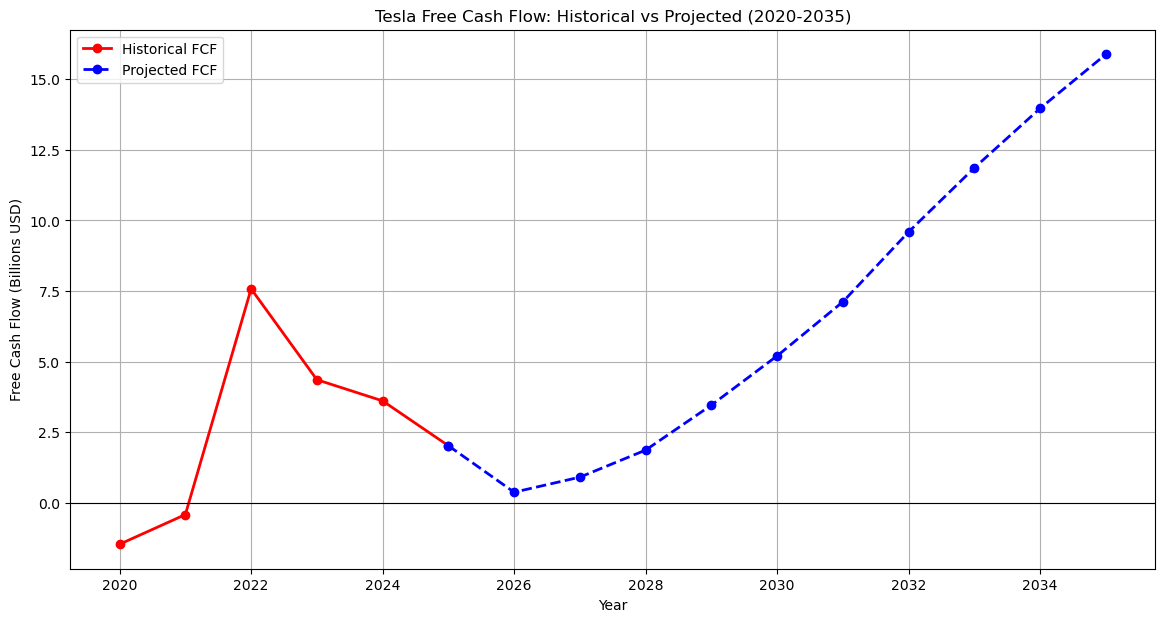

In [25]:
# Combined Historical and Projected FCF Chart
historical_fcf = {
    2020: -1.469,
    2021: -0.419,
    2022: 7.577,
    2023: 4.358,
    2024: 3.608,
    2025: 2.020
}

hist_years = list(historical_fcf.keys())
hist_values = list(historical_fcf.values())

# Bridge point to connect the two lines
bridge_years = [2025] + projection_df['Year'].tolist()
bridge_fcf = [2.020] + projection_df['FCF'].tolist()

plt.figure(figsize=(14, 7))
plt.plot(hist_years, hist_values, 
         marker='o', color='red', linewidth=2, label='Historical FCF')
plt.plot(bridge_years, bridge_fcf, 
         marker='o', color='blue', linewidth=2, 
         linestyle='--', label='Projected FCF')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
plt.title('Tesla Free Cash Flow: Historical vs Projected (2020-2035)')
plt.xlabel('Year')
plt.ylabel('Free Cash Flow (Billions USD)')
plt.legend()
plt.grid(True)
plt.show()